# Embryo Stage Classification

### This notebook trains MobileNetV2 + LSTM  for embryo stage classification:



In [1]:
import os
import copy
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import (
    mobilenet_v2,
    MobileNet_V2_Weights,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cuda


In [2]:
DATA_DIR = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset/'
ANN_DIR = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations'

PHASES = [
    'tPB2', 'tPNa', 'tPNf', 't2', 't3', 't4', 't5', 't6', 't7', 't8', 't9+',
    'tM', 'tSB', 'tB', 'tEB', 'tHB'
]

label_map = {phase: idx for idx, phase in enumerate(PHASES)}

@dataclass
class Config:
    sample_rate: int = 1  
    embryo_fraction: float = 0.6  
    epochs: int = 5
    batch_size: int = 8
    inception_batch_size: int = 16
    image_size: int = 224
    inception_size: int = 299
    lr: float = 1e-4
    weight_decay: float = 1e-4
    num_workers: int = 2
    random_state: int = 42
    label_smoothing: float = 0.1
    grad_clip: float = 1.0
    dist_lambda: float = 0.25
    aux_weight: float = 0.4
    merge_source: int = 15
    merge_target: int = 14

cfg = Config()
print(cfg)

Config(sample_rate=1, embryo_fraction=0.6, epochs=5, batch_size=8, inception_batch_size=16, image_size=224, inception_size=299, lr=0.0001, weight_decay=0.0001, num_workers=2, random_state=42, label_smoothing=0.1, grad_clip=1.0, dist_lambda=0.25, aux_weight=0.4, merge_source=15, merge_target=14)


In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.random_state)

## Build Sampled Dataframe

Frames are sampled once every `sample_rate` frames inside each annotated interval.


In [4]:
def build_dataframe(sample_rate: int = 1, embryo_fraction: float = 0.6) -> pd.DataFrame:
    rows = []

    annotation_files = sorted([f for f in os.listdir(ANN_DIR) if f.endswith('.csv')])

    #  Select only 60% embryos
    random.shuffle(annotation_files)
    num_selected = int(len(annotation_files) * embryo_fraction)
    selected_files = annotation_files[:num_selected]

    print(f"Using {num_selected}/{len(annotation_files)} embryos")

    for file_name in tqdm(selected_files, desc='Reading annotations'):
        embryo_id = file_name.replace('_phases.csv', '')
        ann_path = os.path.join(ANN_DIR, file_name)
        image_dir = os.path.join(DATA_DIR, embryo_id)

        if not os.path.isdir(image_dir):
            continue

        image_files = sorted(os.listdir(image_dir))
        if not image_files:
            continue

        ann_df = pd.read_csv(ann_path, header=None, names=['phase', 'start', 'end'])

        for _, row in ann_df.iterrows():
            phase = row['phase']
            if phase not in label_map:
                continue

            start = int(row['start'])
            end = int(row['end'])
            label = label_map[phase]

            for frame_idx in range(start, end, sample_rate):
                if 0 <= frame_idx < len(image_files):
                    rows.append({
                        'image': os.path.join(image_dir, image_files[frame_idx]),
                        'label': label,
                        'embryo': embryo_id,
                    })

    return pd.DataFrame(rows)

df = build_dataframe(cfg.sample_rate, cfg.embryo_fraction)

print('Total samples:', len(df))
display(df.head())

Using 422/704 embryos


Reading annotations:   0%|          | 0/422 [00:00<?, ?it/s]

Total samples: 172634


,image,label,embryo
0,/kaggle/input/datasets/abhishekbuddiga06/embry...,0,PA145-2
1,/kaggle/input/datasets/abhishekbuddiga06/embry...,0,PA145-2
2,/kaggle/input/datasets/abhishekbuddiga06/embry...,0,PA145-2
3,/kaggle/input/datasets/abhishekbuddiga06/embry...,0,PA145-2
4,/kaggle/input/datasets/abhishekbuddiga06/embry...,0,PA145-2


In [5]:
embryos = df['embryo'].unique()

train_ids, temp_ids = train_test_split(embryos, test_size=0.30, random_state=cfg.random_state, shuffle=True)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.50, random_state=cfg.random_state, shuffle=True)

train_df = df[df['embryo'].isin(train_ids)].copy()
val_df = df[df['embryo'].isin(val_ids)].copy()
test_df = df[df['embryo'].isin(test_ids)].copy()

print('Split sizes before merge')
print('Train:', len(train_df))
print('Val  :', len(val_df))
print('Test :', len(test_df))

Split sizes before merge
Train: 121225
Val  : 25448
Test : 25961


In [6]:
print('Train label counts before merge:')
display(train_df['label'].value_counts().sort_index())

for split_df in [train_df, val_df, test_df]:
    split_df.loc[split_df['label'] == cfg.merge_source, 'label'] = cfg.merge_target

num_classes = len(PHASES) - 1

print('Train label counts after merge:')
display(train_df['label'].value_counts().sort_index())
print('Effective num_classes:', num_classes)

Train label counts before merge:


label
0      3562
1     18053
2      2546
3     11899
4      2069
5     12293
6      3023
7      3472
8      3662
9     14057
10    20350
11     6984
12     7197
13     4274
14     7727
15       57
Name: count, dtype: int64

Train label counts after merge:


label
0      3562
1     18053
2      2546
3     11899
4      2069
5     12293
6      3023
7      3472
8      3662
9     14057
10    20350
11     6984
12     7197
13     4274
14     7784
Name: count, dtype: int64

Effective num_classes: 15


In [7]:
classes = np.arange(num_classes)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_df['label'].values)
class_weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

weight_table = pd.DataFrame({
    'class_id': classes,
    'weight': weights,
})
display(weight_table)

,class_id,weight
0,0,2.268856
1,1,0.447663
2,2,3.174260
3,3,0.679189
4,4,3.906074
5,5,0.657420
6,6,2.673393
7,7,2.327669
8,8,2.206900
9,9,0.574921


## Dataset And Dataloaders


In [8]:
train_transform = transforms.Compose([
    transforms.Resize((cfg.image_size, cfg.image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

eval_transform = transforms.Compose([
    transforms.Resize((cfg.image_size, cfg.image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

In [9]:
class EmbryoSequenceDataset(Dataset):
    def __init__(self, df, transform=None, seq_len=6):
        self.transform = transform
        self.seq_len = seq_len
        self.samples = []

        for embryo_id, group in df.groupby("embryo"):
            group = group.sort_values("image")  # time order

            images = group["image"].tolist()
            labels = group["label"].tolist()

            for i in range(0, len(images) - seq_len, 2):  # step=2
                seq_imgs = images[i:i+seq_len]
                label = labels[i+seq_len-1]  # last frame label
                self.samples.append((seq_imgs, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        paths, label = self.samples[idx]

        imgs = []
        for p in paths:
            try:
                img = Image.open(p).convert("RGB")
            except:
                img = Image.new("RGB", (cfg.image_size, cfg.image_size))

            if self.transform:
                img = self.transform(img)

            imgs.append(img)

        imgs = torch.stack(imgs)  # (T, C, H, W)

        return imgs, torch.tensor(label, dtype=torch.long)

In [10]:
def make_seq_loader(frame, transform, batch_size, shuffle):
    return DataLoader(
        EmbryoSequenceDataset(frame, transform, seq_len=6),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=cfg.num_workers,
        pin_memory=torch.cuda.is_available(),
    )

seq_loaders = {
    'train': make_seq_loader(train_df, train_transform, 8, True),
    'val': make_seq_loader(val_df, eval_transform, 8, False),
    'test': make_seq_loader(test_df, eval_transform, 8, False),
}

# Model


In [11]:
class CNN_LSTM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        base = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
        self.cnn = base.features

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.lstm = nn.LSTM(
            input_size=1280,
            hidden_size=256,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        B, T, C, H, W = x.shape

        x = x.view(B*T, C, H, W)

        feat = self.cnn(x)
        feat = self.pool(feat)
        feat = feat.view(B, T, -1)

        lstm_out, _ = self.lstm(feat)

        out = lstm_out[:, -1, :]
        out = self.fc(out)

        return out

In [12]:
model = CNN_LSTM(num_classes).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 125MB/s]


In [13]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def evaluate(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)   # (B, T, C, H, W)
            labels = labels.to(DEVICE)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="macro")
    cm  = confusion_matrix(all_labels, all_preds)

    return acc, f1, cm

In [14]:
from tqdm.auto import tqdm

train_losses = []
val_accs = []
val_f1s = []

EPOCHS = cfg.epochs

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # -------- TRAIN --------
    model.train()
    train_loss = 0

    loop = tqdm(seq_loaders['train'], desc="Training", leave=False)

    for images, labels in loop:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        optimizer.step()

        train_loss += loss.item()

        # live update
        loop.set_postfix(loss=loss.item())

    train_loss /= len(seq_loaders['train'])
    train_losses.append(train_loss)

    # -------- VALIDATION --------
    val_acc, val_f1, _ = evaluate(model, seq_loaders['val'])

    val_accs.append(val_acc)
    val_f1s.append(val_f1)

    print(f"Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")


Epoch 1/5


Training:   0%|          | 0/7477 [00:00<?, ?it/s]

Train Loss: 1.5805 | Val Acc: 0.3486 | Val F1: 0.2567

Epoch 2/5


Training:   0%|          | 0/7477 [00:00<?, ?it/s]

Train Loss: 1.0523 | Val Acc: 0.3544 | Val F1: 0.2621

Epoch 3/5


...

Train Loss: 0.8532 | Val Acc: 0.3645 | Val F1: 0.2719

Epoch 4/5


Training:   0%|          | 0/7477 [00:00<?, ?it/s]

Train Loss: 0.7397 | Val Acc: 0.3808 | Val F1: 0.2715

Epoch 5/5


Training:   0%|          | 0/7477 [00:00<?, ?it/s]

Train Loss: 0.6666 | Val Acc: 0.3671 | Val F1: 0.2764


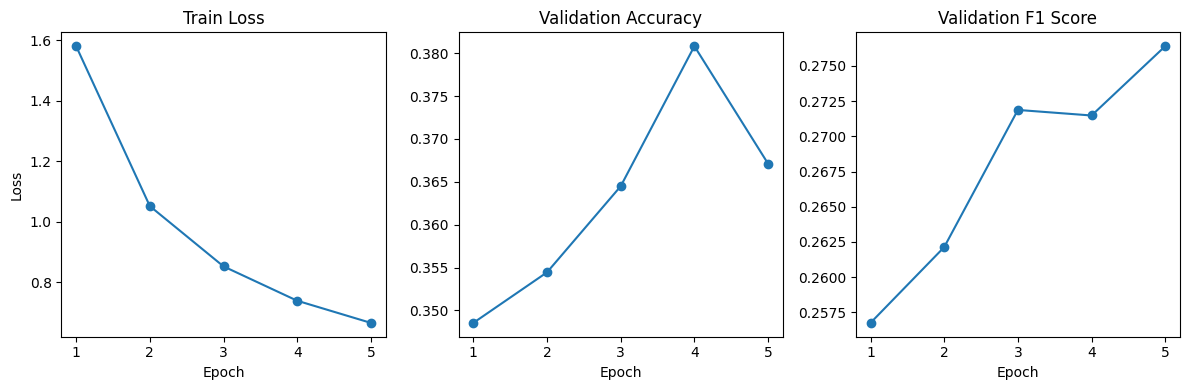

In [15]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,3,1)
plt.plot(epochs_range, train_losses, marker='o')
plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Accuracy
plt.subplot(1,3,2)
plt.plot(epochs_range, val_accs, marker='o')
plt.title("Validation Accuracy")
plt.xlabel("Epoch")

# F1 Score
plt.subplot(1,3,3)
plt.plot(epochs_range, val_f1s, marker='o')
plt.title("Validation F1 Score")
plt.xlabel("Epoch")

plt.tight_layout()
plt.show()

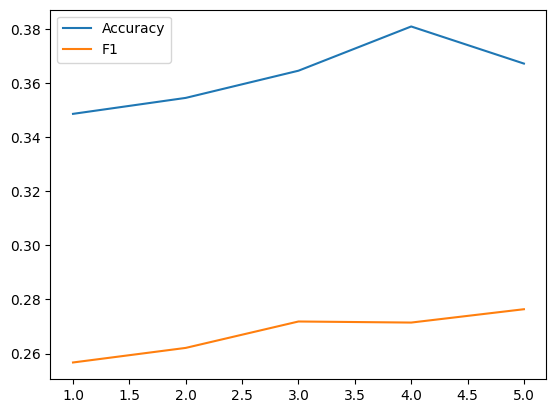

In [16]:
plt.plot(epochs_range, val_accs, label="Accuracy")
plt.plot(epochs_range, val_f1s, label="F1")
plt.legend()

# Evaluation

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion(cm, title="Confusion Matrix"):
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, cmap="Blues")
    
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

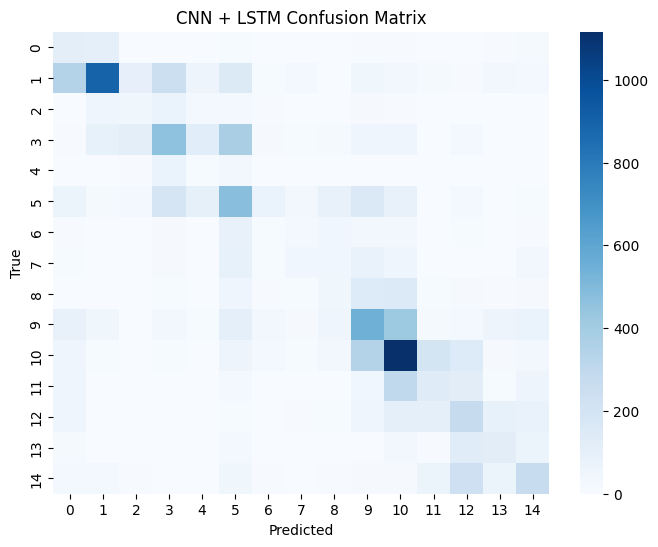

In [18]:
test_acc, test_f1, cm = evaluate(model, seq_loaders['test'])

plot_confusion(cm, "CNN + LSTM Confusion Matrix")